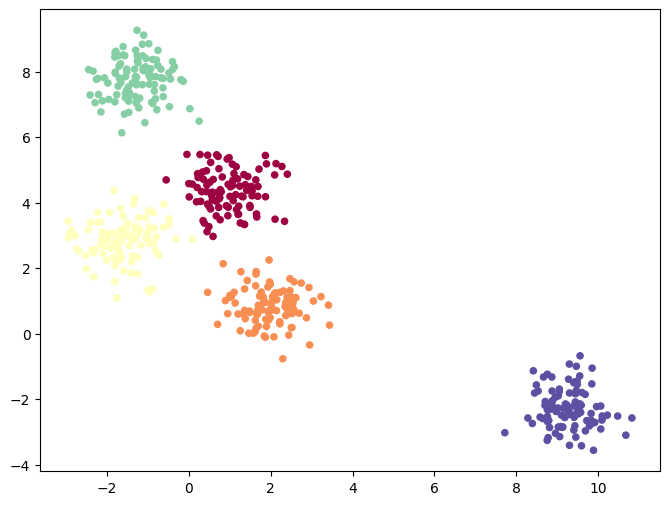

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, 
                  cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val) 
                  for val in np.linspace(0, 1, len(set(y)))])

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c = colors[y], s = 20)
plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

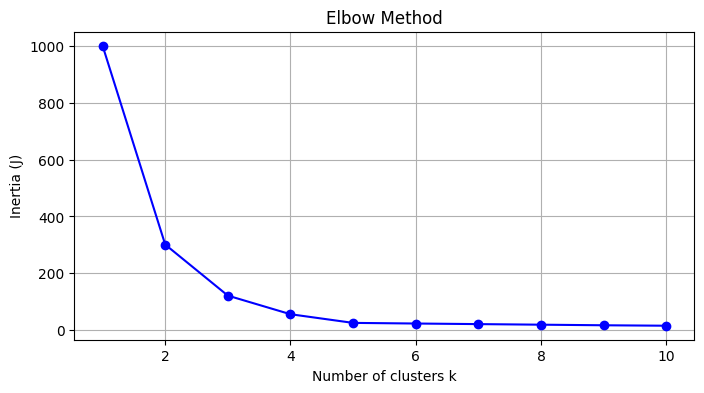

In [33]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-')
plt.title("Elbow Method")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (J)")
plt.grid(True)
plt.show()

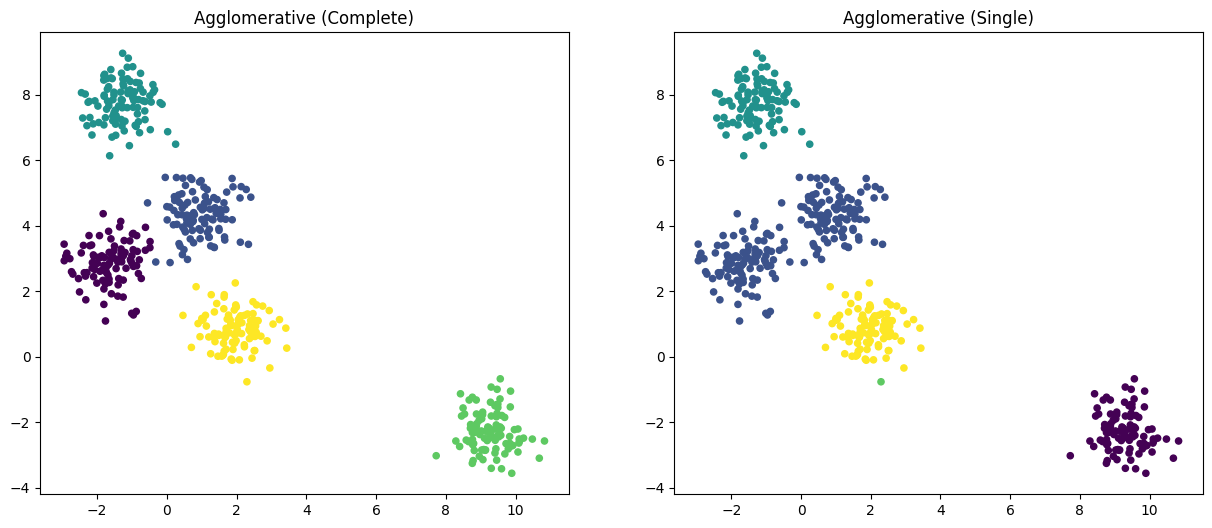

In [35]:
from sklearn.cluster import AgglomerativeClustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

agg_comp = AgglomerativeClustering(n_clusters=5, linkage='complete').fit_predict(X_scaled)
ax1.scatter(X[:, 0], X[:, 1], c=agg_comp, cmap='viridis', s=20)
ax1.set_title("Agglomerative (Complete)")

agg_sing = AgglomerativeClustering(n_clusters=5, linkage='single').fit_predict(X_scaled)
ax2.scatter(X[:, 0], X[:, 1], c=agg_sing, cmap='viridis', s=20)
ax2.set_title("Agglomerative (Single)")

plt.show()